# The Feautrier method

`spectra.RadiativeTransfer.Feautrier` ports RH's `rhf1d/feautrier.c`. It solves
the second-order form of the transfer equation for

$$j(\tau) = \tfrac12\left(I^{+}(\tau) + I^{-}(\tau)\right),
\qquad \mu^{2}\frac{d^{2} j}{d\tau^{2}} = j - S ,$$

along a single ray, at a single frequency, by tridiagonal elimination.

This notebook is **generated** from `build_notebook.py` in this folder.
Re-run the script after any change to the Feautrier API.

## What the solver returns

`formal_improved_RH_(tau, S, mu, r0, h0, rn, hn, order, with_psi)` returns a
`Feautrier_Result` named tuple:

| field | meaning |
|---|---|
| `j` | $\tfrac12(I^{+}+I^{-})$ at every depth |
| `I_emergent` | $I^{+}$ at the upper boundary |
| `Psi` | $\mathrm{diag}(T^{-1}) = \partial j/\partial S$ — the local operator ALI needs (only when `with_psi=True`) |

## Boundary conditions

Both boundaries are written in reflect-plus-source form,

$$I^{-}_{0} = r_0 I^{+}_{0} + h_0, \qquad I^{+}_{N} = r_N I^{-}_{N} + h_N ,$$

which covers every standard case with two numbers per boundary:

| case | `r0, h0` | `rn, hn` |
|---|---|---|
| no incident radiation | `0, 0` | `0, 0` |
| irradiated | `0, I_incident` | `0, I_incident` |
| thermalized (diffusion limit) | — | `0, B + mu dB/dtau` |
| reflective / symmetric slab | `1, 0` | `1, 0` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spectra.Enums import E_FEAUTRIER_ORDER
from spectra.Math import GaussLeg
from spectra.RadiativeTransfer import Feautrier

SECOND = E_FEAUTRIER_ORDER.SECOND
HERMITE = E_FEAUTRIER_ORDER.HERMITE

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "legend.frameon": False})


## 1. Formal solution vs closed-form solutions

Three problems whose solutions are exact — no closure approximation, no
reference implementation, just calculus.

**(a) Finite slab, $S=\mathrm{const}$, no incident radiation.** Integrating
$I^{\pm}$ directly,

$$j(\tau) = S\left[1 - \tfrac12\left(e^{-\tau/\mu} + e^{-(T-\tau)/\mu}\right)\right],
\qquad I^{+}(0) = S\left(1 - e^{-T/\mu}\right).$$

**(b) Pure attenuation**, $S=0$ with incident $h_0$ and $h_N$:

$$j(\tau) = \tfrac12\left(h_0 e^{-\tau/\mu} + h_N e^{-(T-\tau)/\mu}\right).$$

**(c) Linear source** $S = a + b\tau$ with the diffusion-limit lower boundary
$h_N = S_N + \mu b$. Then the Eddington-Barbier relation is *exact*, for any
slab thickness:

$$I^{+}(0) = a + b\mu .$$


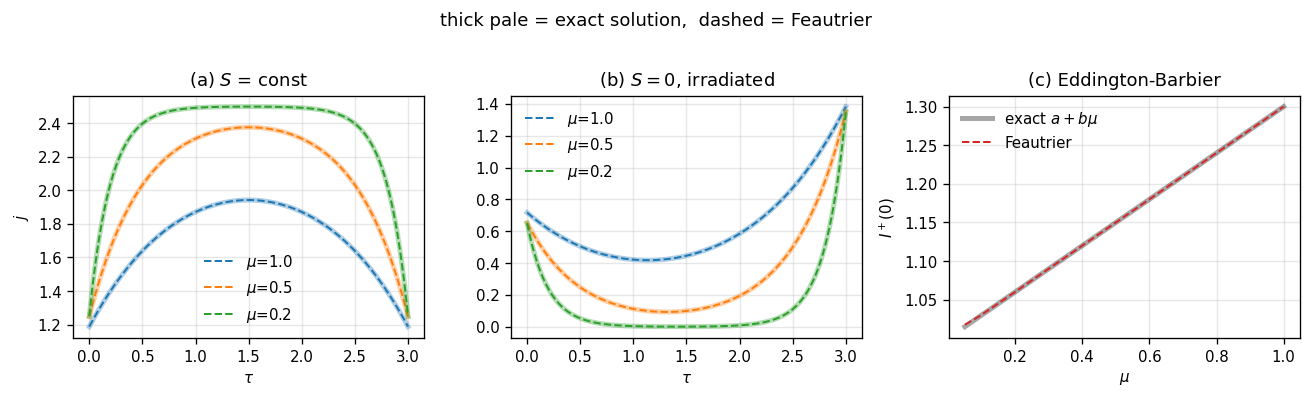

In [2]:
def j_const_source(tau, T, mu, S0):
    return S0 * (1.0 - 0.5 * (np.exp(-tau / mu) + np.exp(-(T - tau) / mu)))

def j_attenuation(tau, T, mu, h0, hn):
    return 0.5 * (h0 * np.exp(-tau / mu) + hn * np.exp(-(T - tau) / mu))

T, ND = 3.0, 201
tau = np.linspace(0.0, T, ND)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

# (a) constant source
S0 = 2.5
ax = axes[0]
for mu, c in zip((1.0, 0.5, 0.2), ("C0", "C1", "C2")):
    res = Feautrier.formal_improved_RH_(tau, np.full(ND, S0), mu, 0., 0., 0., 0.)
    ax.plot(tau, j_const_source(tau, T, mu, S0), c, lw=3, alpha=0.35)
    ax.plot(tau, res.j, c + "--", lw=1.2, label=rf"$\mu$={mu}")
ax.set(title="(a) $S$ = const", xlabel=r"$\tau$", ylabel="$j$")
ax.legend()

# (b) pure attenuation
h0, hn = 1.3, 2.7
ax = axes[1]
for mu, c in zip((1.0, 0.5, 0.2), ("C0", "C1", "C2")):
    res = Feautrier.formal_improved_RH_(tau, np.zeros(ND), mu, 0., h0, 0., hn)
    ax.plot(tau, j_attenuation(tau, T, mu, h0, hn), c, lw=3, alpha=0.35)
    ax.plot(tau, res.j, c + "--", lw=1.2, label=rf"$\mu$={mu}")
ax.set(title="(b) $S=0$, irradiated", xlabel=r"$\tau$")
ax.legend()

# (c) Eddington-Barbier
a, b = 1.0, 0.3
tau_l = np.linspace(0.0, 20.0, 2001)
S_l = a + b * tau_l
mus_plot = np.linspace(0.05, 1.0, 25)
I_num = [Feautrier.formal_improved_RH_(tau_l, S_l, m, 0., 0., 0., S_l[-1] + m * b).I_emergent
         for m in mus_plot]
ax = axes[2]
ax.plot(mus_plot, a + b * mus_plot, "k", lw=3, alpha=0.35, label=r"exact $a+b\mu$")
ax.plot(mus_plot, I_num, "C3--", lw=1.2, label="Feautrier")
ax.set(title=r"(c) Eddington-Barbier", xlabel=r"$\mu$", ylabel="$I^+(0)$")
ax.legend()

fig.suptitle("thick pale = exact solution,  dashed = Feautrier", y=1.02)
fig.tight_layout()
plt.show()


In [3]:
# quantitative agreement
for mu in (1.0, 0.5, 0.2):
    r = Feautrier.formal_improved_RH_(tau, np.full(ND, S0), mu, 0., 0., 0., 0.)
    err_j = np.max(np.abs(r.j - j_const_source(tau, T, mu, S0)))
    err_I = abs(r.I_emergent - S0 * (1.0 - np.exp(-T / mu)))
    print(f"(a) mu={mu:4.2f}  max|dj| = {err_j:.2e}   |dI_emergent| = {err_I:.2e}")

for mu in (1.0, 0.5, 0.2):
    r = Feautrier.formal_improved_RH_(tau_l, S_l, mu, 0., 0., 0., S_l[-1] + mu * b)
    print(f"(c) mu={mu:4.2f}  I_emergent = {r.I_emergent:.8f}  exact = {a + b*mu:.8f}"
          f"   rel = {abs(r.I_emergent/(a + b*mu) - 1):.2e}")


(a) mu=1.00  max|dj| = 1.58e-05   |dI_emergent| = 3.16e-05
(a) mu=0.50  max|dj| = 6.96e-05   |dI_emergent| = 1.39e-04
(a) mu=0.20  max|dj| = 4.39e-04   |dI_emergent| = 8.78e-04
(c) mu=1.00  I_emergent = 1.30000437  exact = 1.30000000   rel = 3.37e-06
(c) mu=0.50  I_emergent = 1.15002125  exact = 1.15000000   rel = 1.85e-05
(c) mu=0.20  I_emergent = 1.06014683  exact = 1.06000000   rel = 1.39e-04


## 2. Boundary conditions

The reflective case is the interesting one, because it can be verified *without
any analytic formula*. A slab of thickness $2T$ carrying a source function
symmetric about its midpoint has $I^{+}=I^{-}$ there by symmetry. So solving the
**half** slab with a reflecting lower boundary (`rn=1, hn=0`) must reproduce the
upper half of the **full** slab solved with `rn=0, hn=0`.

This is a self-consistency identity, and it holds to machine precision.


reflective half-slab vs symmetric full slab: max rel diff = 0.000e+00


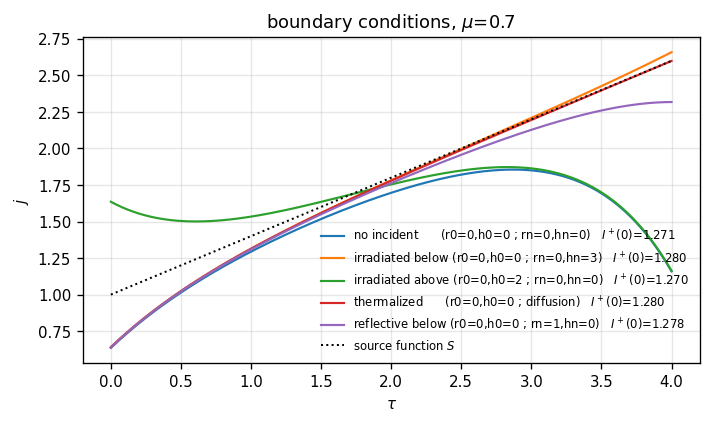

In [4]:
mu = 0.7
n, Th = 201, 2.0
tau_full = np.linspace(0.0, 2.0 * Th, 2 * n - 1)
S_full = 1.0 + np.exp(-tau_full) + np.exp(-(2.0 * Th - tau_full))   # symmetric about Th

full = Feautrier.formal_improved_RH_(tau_full, S_full, mu, 0., 0., 0., 0.)
half = Feautrier.formal_improved_RH_(tau_full[:n], S_full[:n], mu, 0., 0., 1., 0.)

print(f"reflective half-slab vs symmetric full slab: max rel diff = "
      f"{np.max(np.abs(half.j / full.j[:n] - 1)):.3e}")

# the four boundary flavours on one slab
tau_b = np.linspace(0.0, 4.0, 201)
S_b = 1.0 + 0.4 * tau_b
cases = {
    "no incident      (r0=0,h0=0 ; rn=0,hn=0)": (0., 0., 0., 0.),
    "irradiated below (r0=0,h0=0 ; rn=0,hn=3)": (0., 0., 0., 3.0),
    "irradiated above (r0=0,h0=2 ; rn=0,hn=0)": (0., 2.0, 0., 0.),
    "thermalized      (r0=0,h0=0 ; diffusion)": (0., 0., 0., S_b[-1] + mu * 0.4),
    "reflective below (r0=0,h0=0 ; rn=1,hn=0)": (0., 0., 1., 0.),
}
fig, ax = plt.subplots(figsize=(6, 3.6))
for lab, (r0, h0, rn, hn) in cases.items():
    r = Feautrier.formal_improved_RH_(tau_b, S_b, mu, r0, h0, rn, hn)
    ax.plot(tau_b, r.j, lw=1.3, label=f"{lab}   $I^+(0)$={r.I_emergent:.3f}")
ax.plot(tau_b, S_b, "k:", lw=1.2, label="source function $S$")
ax.set(xlabel=r"$\tau$", ylabel="$j$", title=rf"boundary conditions, $\mu$={mu}")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


## 3. Convergence order: `SECOND` vs `HERMITE`

Reference problem with a closed form: finite slab, no incident radiation,
$S=e^{-\beta\tau}$, giving

$$I^{-}(\tau) = \frac{e^{-\beta\tau} - e^{-\tau/\mu}}{1-\beta\mu},\qquad
I^{+}(\tau) = \frac{e^{-\beta\tau} - e^{-\beta T}e^{-(T-\tau)/\mu}}{1+\beta\mu} .$$

**Expect order 3, not 4.** The Hermite corrections raise the *interior* rows from
2nd to 4th order, but the two *boundary* rows gain only one order (2nd → 3rd),
and the boundary is what limits the global rate. This is a property of the
reference implementation, whose "fourth order" refers to the interior scheme —
it is reproduced faithfully here, not a defect of the port. Hermite is still
well worth its cost: roughly two orders of magnitude lower error at a few
hundred depth points.


SECOND   slope = 1.995   errors = ['8.06e-03', '2.05e-03', '5.15e-04', '1.29e-04', '3.22e-05', '8.05e-06']
HERMITE  slope = 2.953   errors = ['1.04e-03', '1.42e-04', '1.86e-05', '2.37e-06', '3.00e-07', '3.77e-08']


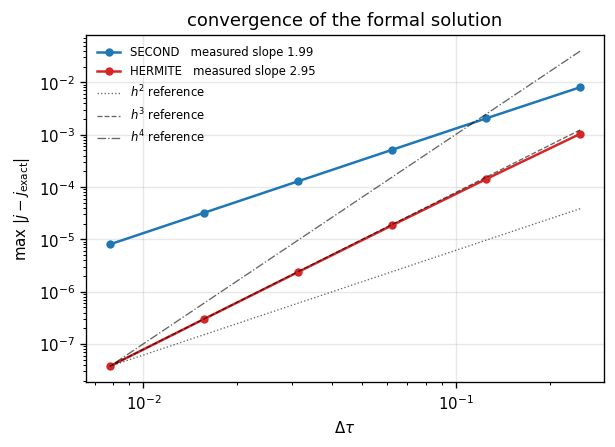

In [5]:
def j_exp_source(tau, T, mu, beta):
    Im = (np.exp(-beta * tau) - np.exp(-tau / mu)) / (1.0 - beta * mu)
    Ip = (np.exp(-beta * tau) - np.exp(-beta * T) * np.exp(-(T - tau) / mu)) / (1.0 + beta * mu)
    return 0.5 * (Ip + Im)

T, mu, beta = 5.0, 0.6, 0.7
NDs = np.array([21, 41, 81, 161, 321, 641])
hs = T / (NDs - 1)

fig, ax = plt.subplots(figsize=(5.2, 3.8))
for order, name, c in ((SECOND, "SECOND", "C0"), (HERMITE, "HERMITE", "C3")):
    errs = []
    for nd in NDs:
        t = np.linspace(0.0, T, nd)
        j = Feautrier.formal_improved_RH_(t, np.exp(-beta * t), mu, 0., 0., 0., 0., order).j
        errs.append(np.max(np.abs(j - j_exp_source(t, T, mu, beta))))
    errs = np.array(errs)
    slope = np.polyfit(np.log(hs), np.log(errs), 1)[0]
    ax.loglog(hs, errs, c + "o-", ms=4, label=f"{name}   measured slope {slope:.2f}")
    print(f"{name:8s} slope = {slope:.3f}   errors = {['%.2e' % e for e in errs]}")

for p, st in ((2, ":"), (3, "--"), (4, "-.")):
    ax.loglog(hs, errs[-1] * (hs / hs[-1]) ** p, "k" + st, lw=0.8, alpha=0.6,
              label=rf"$h^{p}$ reference")
ax.set(xlabel=r"$\Delta\tau$", ylabel=r"max $|j - j_{\rm exact}|$",
       title="convergence of the formal solution")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


## 4. The two-level atom: $\Lambda$-iteration vs ALI vs direct

Monochromatic two-level atom with coherent scattering,

$$S = (1-\varepsilon) J + \varepsilon B ,$$

in a semi-infinite isothermal atmosphere ($B=1$, $\varepsilon=10^{-2}$).

### The three approaches

**`direct_feautrier_`** carries the angle coupling of the scattering integral
inside the block-tridiagonal elimination, so it solves the coupled problem in a
single pass — no iteration. It is the reference here.

**$\Lambda$-iteration** simply repeats $S \leftarrow (1-\varepsilon)\Lambda[S] +
\varepsilon B$. It famously stalls: information diffuses one optical depth per
iteration.

**ALI** splits $\Lambda = \Lambda^{*} + (\Lambda - \Lambda^{*})$ and treats the
local part implicitly. With the returned diagonal operator,

$$\Lambda^{*}_{k} = \sum_{\mu} w_{\mu}\,\Psi_{\mu,k},
\qquad
S^{\rm new}_{k} = \frac{(1-\varepsilon)\left(J^{\rm FS}_{k}
   - \Lambda^{*}_{k} S^{\rm old}_{k}\right) + \varepsilon B_{k}}
  {1 - (1-\varepsilon)\Lambda^{*}_{k}} .$$

That is the whole preconditioning — three lines, fully local, no matrix. Note
that RH never builds an $N_D \times N_D$ $\Lambda$ operator for this: the
diagonal comes out of the same elimination in $O(N_D)$.

### The $\sqrt{\varepsilon}$ law

For a semi-infinite isothermal atmosphere the surface value obeys
$S(0)/B = \sqrt{\varepsilon}$ — a sharp, single-number check on the direct solver.


In [6]:
ND = 101
tau2 = np.logspace(-4.0, 4.0, ND)
B = np.ones(ND)
eps_val = 1e-2
eps = np.full(ND, eps_val)
mus, ws = GaussLeg.gauss_quad_coe_(0.0, 1.0, 4)

S_direct = Feautrier.direct_feautrier_(tau2, np.zeros(4), np.full(4, B[-1]), B, eps)
print(f"direct: S(0) = {S_direct[0]:.6f}   sqrt(eps) = {np.sqrt(eps_val):.6f}"
      f"   rel = {abs(S_direct[0]/np.sqrt(eps_val) - 1):.2e}")


def iterate(lambda_star_scale, n_iter=400, tol=1e-10, snapshots=()):
    # lambda_star_scale = 1 -> ALI;  0 -> plain Lambda-iteration
    S = B.copy()
    hist, snaps = [], {}
    for it in range(n_iter):
        J_fs = np.zeros(ND)
        L_star = np.zeros(ND)
        for i in range(mus.size):
            r = Feautrier.formal_improved_RH_(tau2, S, mus[i], 0., 0., 0., B[-1],
                                              SECOND, True)
            J_fs += ws[i] * r.j
            L_star += ws[i] * r.Psi
        L_star = L_star * lambda_star_scale
        S_new = ((1 - eps) * (J_fs - L_star * S) + eps * B) / (1 - (1 - eps) * L_star)
        change = np.max(np.abs(S_new / S - 1.0))
        S = S_new
        hist.append(change)
        if it + 1 in snapshots:
            snaps[it + 1] = S.copy()
        if change < tol:
            break
    return S, hist, snaps


snap_at = (1, 2, 5, 10, 30)
S_ali, hist_ali, snaps_ali = iterate(1.0, snapshots=snap_at)
S_li, hist_li, snaps_li = iterate(0.0, snapshots=snap_at)
print(f"ALI            : {len(hist_ali):4d} iterations, "
      f"max rel vs direct = {np.max(np.abs(S_ali/S_direct - 1)):.2e}")
print(f"Lambda-iteration: {len(hist_li):4d} iterations, "
      f"max rel vs direct = {np.max(np.abs(S_li/S_direct - 1)):.2e}")


direct: S(0) = 0.100182   sqrt(eps) = 0.100000   rel = 1.82e-03


ALI            :  270 iterations, max rel vs direct = 1.22e-09
Lambda-iteration:  400 iterations, max rel vs direct = 9.34e-04


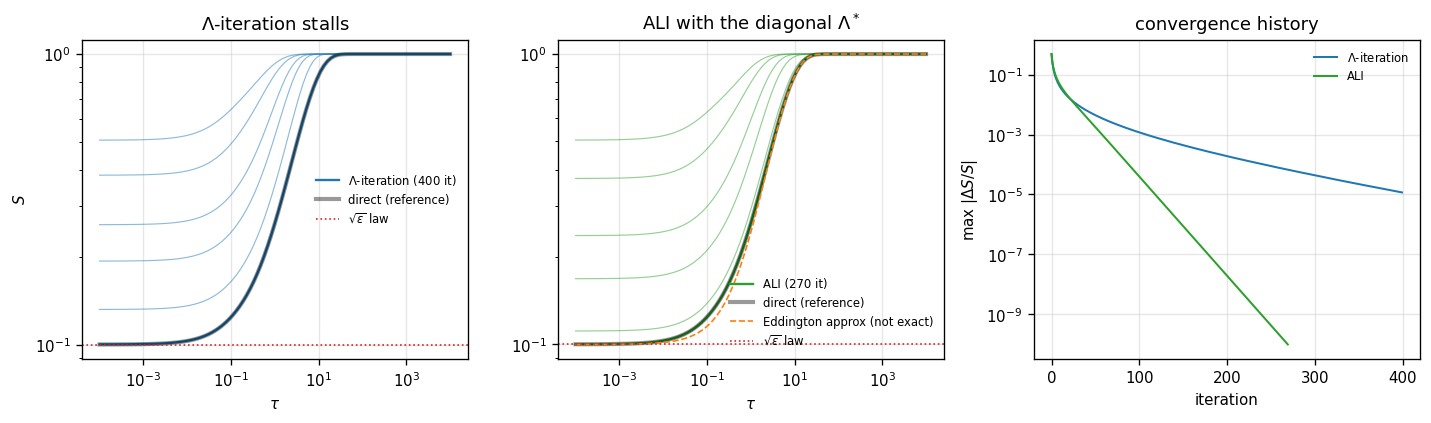

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

# Eddington-approximation reference -- NOT exact, shown for context only
J_edd = 1.0 - (np.sqrt(3.0) / (np.sqrt(3.0) * (1.0 + np.sqrt(eps_val)))) * \
        np.exp(-np.sqrt(3.0 * eps_val) * tau2)
S_edd = (1 - eps) * J_edd + eps * B

ax = axes[0]
for n, s in snaps_li.items():
    ax.loglog(tau2, s, "C0-", lw=0.7, alpha=0.5)
ax.loglog(tau2, S_li, "C0-", lw=1.4, label=f"$\\Lambda$-iteration ({len(hist_li)} it)")
ax.loglog(tau2, S_direct, "k", lw=2.5, alpha=0.4, label="direct (reference)")
ax.axhline(np.sqrt(eps_val), color="C3", ls=":", lw=1,
           label=r"$\sqrt{\varepsilon}$ law")
ax.set(xlabel=r"$\tau$", ylabel="$S$",
       title=r"$\Lambda$-iteration stalls")
ax.legend(fontsize=7)

ax = axes[1]
for n, s in snaps_ali.items():
    ax.loglog(tau2, s, "C2-", lw=0.7, alpha=0.5)
ax.loglog(tau2, S_ali, "C2-", lw=1.4, label=f"ALI ({len(hist_ali)} it)")
ax.loglog(tau2, S_direct, "k", lw=2.5, alpha=0.4, label="direct (reference)")
ax.loglog(tau2, S_edd, "C1--", lw=1.0, label="Eddington approx (not exact)")
ax.axhline(np.sqrt(eps_val), color="C3", ls=":", lw=1,
           label=r"$\sqrt{\varepsilon}$ law")
ax.set(xlabel=r"$\tau$", title=r"ALI with the diagonal $\Lambda^*$")
ax.legend(fontsize=7)

ax = axes[2]
ax.semilogy(hist_li, "C0-", lw=1.2, label=r"$\Lambda$-iteration")
ax.semilogy(hist_ali, "C2-", lw=1.2, label="ALI")
ax.set(xlabel="iteration", ylabel=r"max $|\Delta S / S|$",
       title="convergence history")
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()


### Why an *approximate* $\Lambda^{*}$ is still safe

Substituting $S^{\rm new}=S^{\rm old}=S$ and $J^{\rm FS}=\Lambda S$ into the ALI
update,

$$S = (1-\varepsilon)\left[\Lambda^{*}S + \Lambda S - \Lambda^{*}S\right]
 + \varepsilon B = (1-\varepsilon)\Lambda S + \varepsilon B ,$$

the $\Lambda^{*}$ terms **cancel identically**. The converged solution is
therefore independent of $\Lambda^{*}$; only the convergence *rate* depends on
it. That is what licenses returning the approximate `Psi` under `HERMITE`
(where Hermite folds $S_{k\pm1}$ into the right-hand side, so
$\Lambda = T^{-1}M$ and the exact diagonal would need the near-diagonal band of
$T^{-1}$).

The check below deliberately corrupts $\Lambda^{*}$ and confirms the iteration
still lands on the same $S(\tau)$.


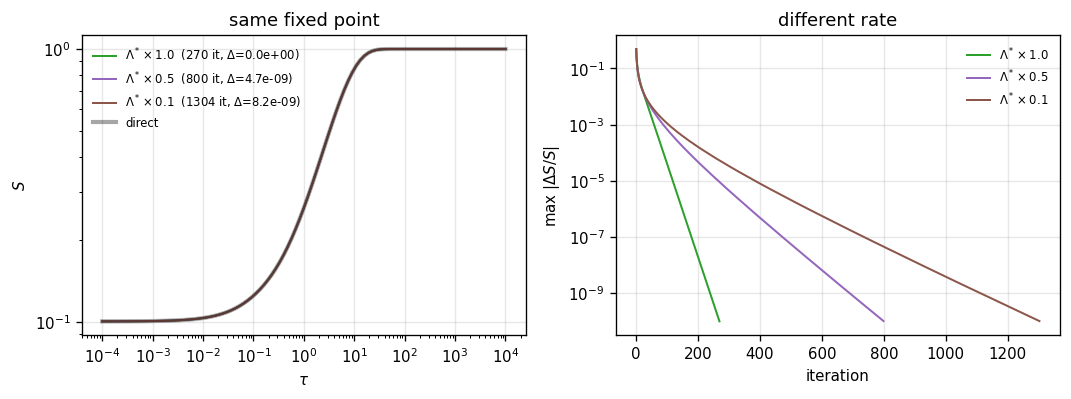

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for scale, c in ((1.0, "C2"), (0.5, "C4"), (0.1, "C5")):
    S_s, hist_s, _ = iterate(scale, n_iter=2000)
    ax[0].loglog(tau2, S_s, c, lw=1.2,
                 label=rf"$\Lambda^*\times${scale}  ({len(hist_s)} it, "
                       rf"$\Delta$={np.max(np.abs(S_s/S_ali - 1)):.1e})")
    ax[1].semilogy(hist_s, c, lw=1.2, label=rf"$\Lambda^*\times${scale}")
ax[0].loglog(tau2, S_direct, "k", lw=2.5, alpha=0.35, label="direct")
ax[0].set(xlabel=r"$\tau$", ylabel="$S$", title="same fixed point")
ax[0].legend(fontsize=7)
ax[1].set(xlabel="iteration", ylabel=r"max $|\Delta S/S|$", title="different rate")
ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()


## Summary

- The formal solution reproduces every closed-form problem tested, and the
  reflective boundary matches the symmetric double slab to machine precision.
- `SECOND` converges at order 2; `HERMITE` at order **3**, limited by its
  boundary rows rather than its 4th-order interior — faithful to the reference
  implementation, and still ~100x more accurate at practical resolutions.
- `direct_feautrier_` reproduces the $\sqrt{\varepsilon}$ surface law and serves
  as the non-iterative reference.
- The returned `Psi` is all that ALI needs: $\Lambda$-iteration stalls where ALI
  converges, and the ALI fixed point is provably independent of $\Lambda^{*}$.

Everything shown here is also asserted in `tests/unittest/test.Feautrier.py`,
so the figures cannot silently drift from the code.

**Not covered:** multilevel MALI, i.e. preconditioning the full rate matrix
$\Gamma$ in the statistical-equilibrium solver. That is a separate, larger piece
of work; the diagonal operator delivered here is its prerequisite.
